In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

penguins_df = pd.read_csv("penguins.csv")
penguins_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE


In [22]:
penguins_df.isnull().sum()

culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [23]:
penguins_df=pd.get_dummies(penguins_df,drop_first=True)
penguins_df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_MALE
0,39.1,18.7,181.0,3750.0,1
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
3,36.7,19.3,193.0,3450.0,0
4,39.3,20.6,190.0,3650.0,1


In [24]:
scaler = StandardScaler()
penguins_scaled = scaler.fit_transform(penguins_df)

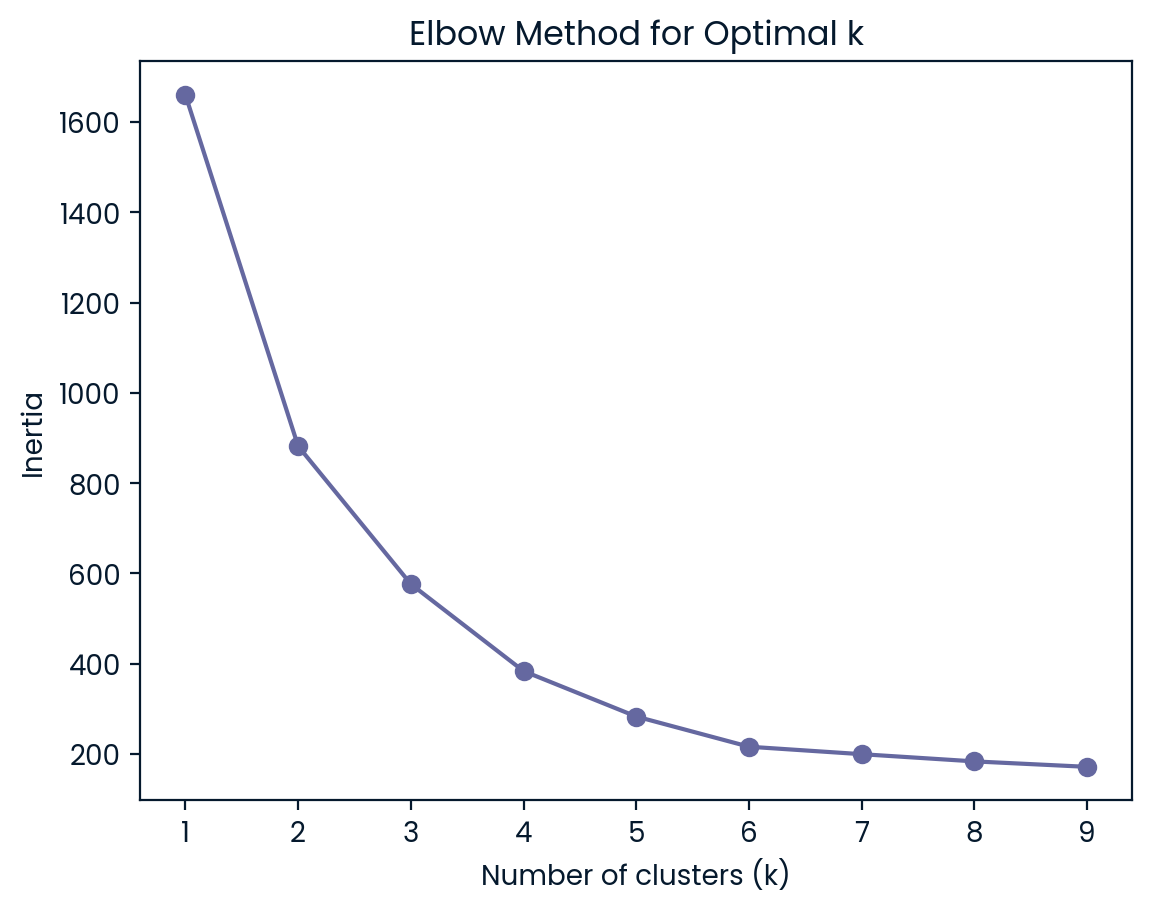

In [25]:
inertia=[]
for i in range(1,10):
  kmean=KMeans(n_clusters=i, random_state=42)  
  kmean.fit(penguins_scaled)
  inertia.append(kmean.inertia_)

plt.figure()
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

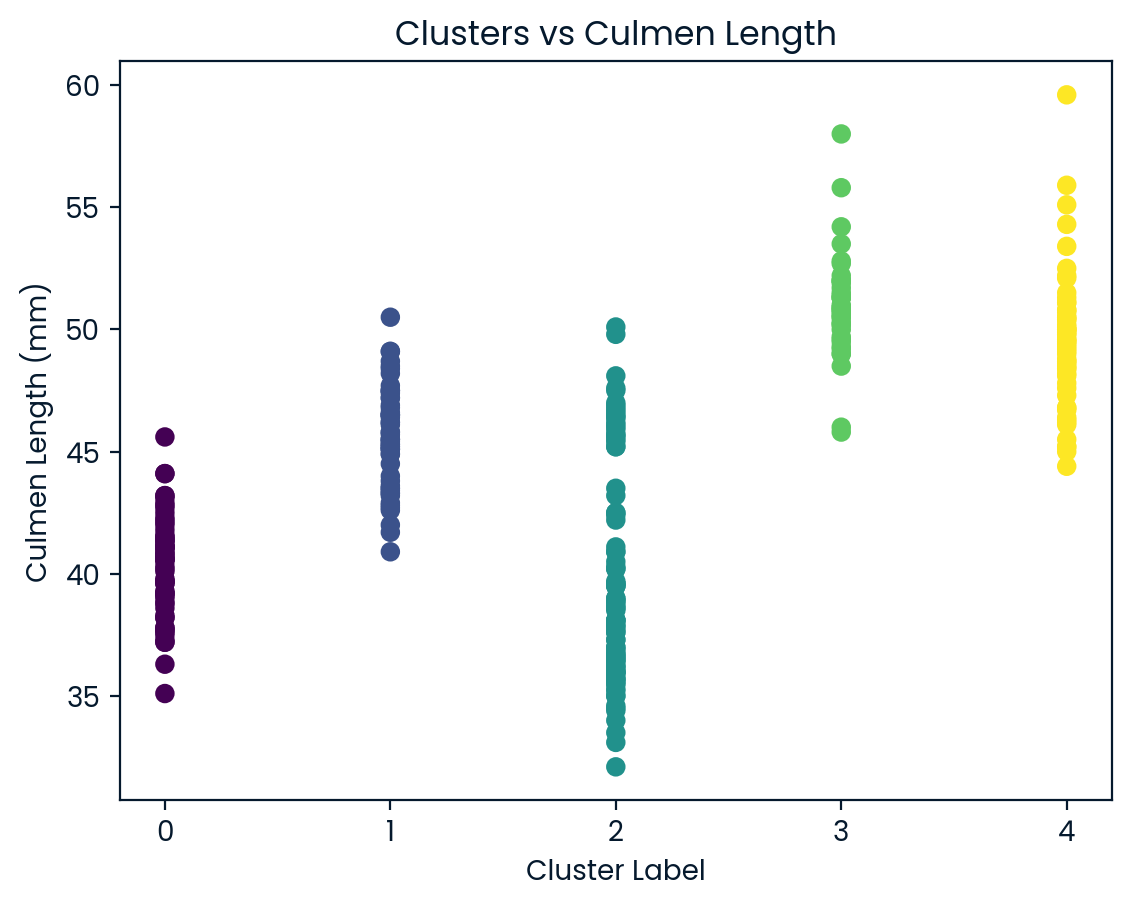

In [26]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(penguins_scaled)

penguins_df['cluster'] = kmeans.labels_

plt.figure()
plt.scatter(
    penguins_df['cluster'],          
    penguins_df['culmen_length_mm'], 
    c=kmeans.labels_
)
plt.xticks(np.arange(0, 5, 1))
plt.xlabel('Cluster Label')
plt.ylabel('Culmen Length (mm)')
plt.title('Clusters vs Culmen Length')
plt.show()

In [ ]:
numeric_columns = penguins_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

penguins_df['label'] = kmeans.labels_

stat_penguins = (
    penguins_df
    .groupby('label')[numeric_columns]
    .mean()
)

stat_penguins


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
label,,,,
0,40.315714,19.011429,192.242857,4034.642857
1,45.563793,14.237931,212.706897,4679.741379
2,39.744660,17.588350,188.864078,3410.679612
3,50.965000,19.195000,199.075000,3920.625000
4,49.473770,15.718033,221.540984,5484.836066
